In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!cp /content/drive/MyDrive/STGCN_Project/*.npy /content/

In [5]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

In [6]:
# 1. Load datasets

X_train = np.load("/content/X_train.npy")
Y_train = np.load("/content/Y_train.npy")

X_val = np.load("/content/X_val.npy")
Y_val = np.load("/content/Y_val.npy")

X_test = np.load("/content/X_test.npy")
Y_test = np.load("/content/Y_test.npy")

adj = np.load("/content/adjacency_full.npy")

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("Adjacency:", adj.shape)


X_train: (23972, 12, 207, 6)
Y_train: (23972, 6, 207)
Adjacency: (207, 207)


In [7]:
# 2. Normalize adjacency


A = adj
I = np.eye(A.shape[0])

A_hat = A + I

D = np.diag(np.sum(A_hat, axis=1))

D_inv_sqrt = np.linalg.inv(np.sqrt(D))

A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt

adj = A_norm


In [8]:
## convert to PyTorch Tensors

X_train = torch.tensor(X_train, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
Y_val = torch.tensor(Y_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
Y_test = torch.tensor(Y_test, dtype=torch.float32)

In [9]:
# 3. Convert to PyTorch tensors


X_train = torch.tensor(X_train, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
Y_val = torch.tensor(Y_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
Y_test = torch.tensor(Y_test, dtype=torch.float32)

/tmp/ipykernel_52578/3223198962.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32)
/tmp/ipykernel_52578/3223198962.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_train = torch.tensor(Y_train, dtype=torch.float32)
/tmp/ipykernel_52578/3223198962.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_val = torch.tensor(X_val, dtype=torch.float32)
/tmp/ipykernel_52578/3223198962.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone(

In [10]:
# 4. Create DataLoaders


batch_size = 8

train_loader = DataLoader(
    TensorDataset(X_train, Y_train),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, Y_val),
    batch_size=batch_size
)


In [11]:
# 5. Graph Convolution Layer


class GraphConv(nn.Module):

    def __init__(self, in_features, out_features, adj):
        super().__init__()

        self.register_buffer("A", torch.tensor(adj, dtype=torch.float32))
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x):

        # x shape: (batch, time, nodes, features)

        x = torch.einsum("ij,btjf->btif", self.A, x)

        x = self.linear(x)

        return x


In [12]:
##  # 6. STGCN Model


class STGCN(nn.Module):

    def __init__(self, adj, num_features):

        super().__init__()

        # Block 1
        self.temporal1 = nn.Conv2d(num_features, 64, (3,1), padding=(1,0))
        self.graph1 = GraphConv(64, 64, adj)
        self.temporal2 = nn.Conv2d(64, 64, (3,1), padding=(1,0))

        # Block 2
        self.temporal3 = nn.Conv2d(64, 64, (3,1), padding=(1,0))
        self.graph2 = GraphConv(64, 64, adj)
        self.temporal4 = nn.Conv2d(64, 64, (3,1), padding=(1,0))

        self.dropout = nn.Dropout(0.2)

        self.fc = nn.Linear(64, 6)


    def forward(self, x):

        # x = (batch, time, nodes, features)

        x = x.permute(0,3,1,2)

        # Block 1
        x = torch.relu(self.temporal1(x))
        x = self.dropout(x)

        x = x.permute(0,2,3,1)
        x = self.graph1(x)
        x = self.dropout(x)

        x = x.permute(0,3,1,2)
        x = torch.relu(self.temporal2(x))
        x = self.dropout(x)


        # Block 2
        x = torch.relu(self.temporal3(x))
        x = self.dropout(x)

        x = x.permute(0,2,3,1)
        x = self.graph2(x)
        x = self.dropout(x)

        x = x.permute(0,3,1,2)
        x = torch.relu(self.temporal4(x))
        x = self.dropout(x)


        # Final representation
        x = x[:, :, -1, :]

        x = x.permute(0,2,1)

        x = self.fc(x)

        x = x.permute(0,2,1)

        return x

In [13]:
# 7. Initialize model


model = STGCN(adj, 6)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

loss_fn = nn.MSELoss()

epochs = 40   # number of training epochs

In [14]:
best_val_loss = float('inf')
patience = 5
patience_counter = 0

In [20]:
## Training loop

train_losses = []
val_losses = []

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for X, Y in train_loader:

        optimizer.zero_grad()

        pred = model(X)

        loss = loss_fn(pred, Y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)


    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X, Y in val_loader:

            pred = model(X)

            loss = loss_fn(pred, Y)

            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)


    # store losses
    train_losses.append(train_loss)
    val_losses.append(val_loss)


    print(f"Epoch {epoch} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")


    # Early stopping
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(model.state_dict(), "best_stgcn_model.pth")

        print("✔ New best model saved")

    else:

        patience_counter += 1

        print(f"No improvement ({patience_counter}/{patience})")

        if patience_counter >= patience:
            print("Early stopping triggered")
            break

Epoch 0 | Train: 0.2922 | Val: 0.2572
✔ New best model saved
Epoch 1 | Train: 0.2490 | Val: 0.2467
✔ New best model saved
Epoch 2 | Train: 0.2394 | Val: 0.2315
✔ New best model saved
Epoch 3 | Train: 0.2368 | Val: 0.2269
✔ New best model saved
Epoch 4 | Train: 0.2327 | Val: 0.2340
No improvement (1/5)
Epoch 5 | Train: 0.2300 | Val: 0.2294
No improvement (2/5)
Epoch 6 | Train: 0.2278 | Val: 0.2285
No improvement (3/5)
Epoch 7 | Train: 0.2273 | Val: 0.2239
✔ New best model saved
Epoch 8 | Train: 0.2246 | Val: 0.2364
No improvement (1/5)
Epoch 9 | Train: 0.2242 | Val: 0.2200
✔ New best model saved
Epoch 10 | Train: 0.2219 | Val: 0.2270
No improvement (1/5)
Epoch 11 | Train: 0.2221 | Val: 0.2318
No improvement (2/5)
Epoch 12 | Train: 0.2213 | Val: 0.2360
No improvement (3/5)
Epoch 13 | Train: 0.2209 | Val: 0.2291
No improvement (4/5)
Epoch 14 | Train: 0.2202 | Val: 0.2252
No improvement (5/5)
Early stopping triggered


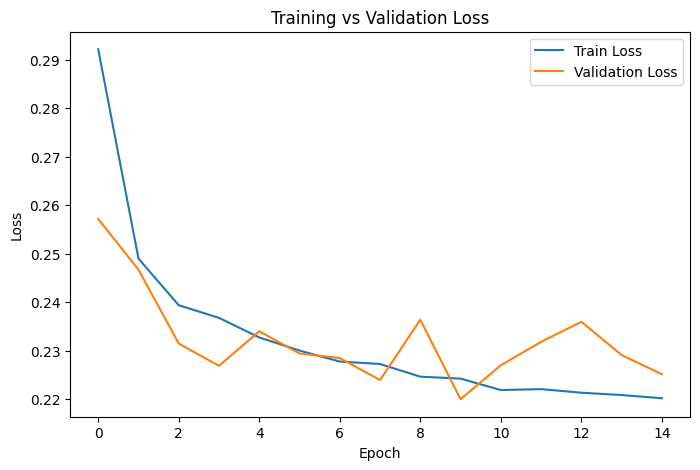

In [21]:
# 9. Plot loss curves


plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()


In [21]:
torch.save(model.state_dict(),
           "/content/drive/MyDrive/STGCN_Project/best_stgcn_model.pth")

In [15]:
import torch
import numpy as np

adj = np.load("/content/adjacency_full.npy")

model = STGCN(adj, 6)

model.load_state_dict(torch.load("/content/best_stgcn_model.pth"))

model.eval()

print("Model restored")

Model restored
